##Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("/content/covertype.csv")
df

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
1,2590,56,2,212,-6,390,220,235,151,6225,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
2,2804,139,9,268,65,3180,234,238,135,6121,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
3,2785,155,18,242,118,3090,238,238,122,6211,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
4,2595,45,2,153,-1,391,220,234,150,6172,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16131,2638,21,25,60,14,1712,195,178,109,6816,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
16132,2634,9,25,90,24,1682,183,181,126,6798,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
16133,2633,8,26,90,40,1652,181,179,126,6780,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
16134,2630,11,26,90,37,1622,182,177,122,6763,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


##Data Exploration

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16136 entries, 0 to 16135
Data columns (total 55 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Unnamed: 0                          16136 non-null  int64  
 1   Unnamed: 1                          16136 non-null  int64  
 2   Unnamed: 2                          16136 non-null  int64  
 3   Elevation                           16136 non-null  int64  
 4   Aspect                              16136 non-null  int64  
 5   Slope                               16136 non-null  int64  
 6   Horizontal_Distance_To_Hydrology    16136 non-null  int64  
 7   Vertical_Distance_To_Hydrology      16136 non-null  int64  
 8   Horizontal_Distance_To_Roadways     16136 non-null  int64  
 9   Hillshade_9am                       16136 non-null  int64  
 10  Hillshade_Noon                      16136 non-null  int64  
 11  Hillshade_3pm                       16136

In [4]:
df.isna().sum()

,0
Unnamed: 0,0
Unnamed: 1,0
Unnamed: 2,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0


In [5]:
df.dropna(axis=0,inplace=True)

In [6]:
df.isna().sum()

,0
Unnamed: 0,0
Unnamed: 1,0
Unnamed: 2,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,16135.000000,16135.000000,16135.000000,16135.000000,16135.000000,16135.000000,16135.000000,16135.000000,16135.000000,16135.000000,...,16135.000000,16135.000000,16135.000000,16135.000000,16135.000000,16135.000000,16135.000000,16135.000000,16135.000000,16135.000000
mean,2746.488503,155.765541,16.603967,220.365603,49.902572,1770.197149,212.427270,218.422374,134.809978,1809.967524,...,0.042764,0.038178,0.001363,0.006322,0.000620,0.002107,0.045119,0.040719,0.028447,3.873071
std,405.084942,111.171048,8.460349,206.152566,59.987845,1329.213796,30.566461,22.913488,45.450182,1576.578834,...,0.202331,0.191631,0.036902,0.079260,0.024888,0.045857,0.207572,0.197644,0.166253,2.004304
min,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2397.000000,63.000000,10.000000,60.000000,5.000000,785.000000,195.000000,206.000000,107.000000,765.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,2746.000000,124.000000,15.000000,175.000000,32.000000,1362.000000,219.000000,222.000000,138.000000,1332.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
75%,3072.000000,261.000000,22.000000,319.000000,76.500000,2462.000000,235.000000,235.000000,166.000000,2223.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
max,3849.000000,360.000000,52.000000,1343.000000,554.000000,6890.000000,254.000000,254.000000,248.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


##Data preprocessing

In [9]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop("Cover_Type",axis=1))

In [10]:
df_scaled

array([[-0.37151015, -0.94241072, -1.60801745, ..., -0.21737353,
        -0.20602753, -0.17111525],
       [-0.38632232, -0.89743359, -1.72621955, ..., -0.21737353,
        -0.20602753, -0.17111525],
       [ 0.14197832, -0.15081319, -0.89880483, ..., -0.21737353,
        -0.20602753, -0.17111525],
       ...,
       [-0.27769976, -1.32021864,  0.99242881, ..., -0.21737353,
        -0.20602753, -0.17111525],
       [-0.28016845, -1.32921406,  1.11063091, ..., -0.21737353,
        -0.20602753, -0.17111525],
       [-0.28757453, -1.30222778,  1.11063091, ..., -0.21737353,
        -0.20602753, -0.17111525]])

In [11]:
df_scaled = pd.DataFrame(df_scaled,columns=df.columns[0:54])

In [12]:
df = pd.concat([df_scaled,df["Cover_Type"]],axis=1)

##Data Modeling

In [13]:
#Split the dataframe to X,y
X = df.drop(["Cover_Type"],axis=1)
y = df["Cover_Type"]

In [14]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=44,shuffle=True, stratify=y)

###LogisticRegression

In [15]:
lr=LogisticRegression(max_iter=100, multi_class="multinomial")
lr.fit(X_train, y_train)
y_pred= lr.predict(X_test)
acc_lr=accuracy_score(y_test,y_pred)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

print(y_test[:10],y_pred[:10])

Logistic Regression Accuracy: 0.713975828943291
              precision    recall  f1-score   support

         1.0       0.68      0.63      0.65       458
         2.0       0.68      0.68      0.68       602
         3.0       0.61      0.53      0.57       432
         4.0       0.83      0.85      0.84       432
         5.0       0.73      0.74      0.73       439
         6.0       0.59      0.66      0.62       432
         7.0       0.87      0.93      0.90       432

    accuracy                           0.71      3227
   macro avg       0.71      0.72      0.71      3227
weighted avg       0.71      0.71      0.71      3227

11161    3.0
9170     7.0
8818     5.0
10033    1.0
7368     7.0
8794     1.0
7093     3.0
10690    6.0
15184    1.0
6195     4.0
Name: Cover_Type, dtype: float64 [3. 7. 6. 2. 7. 2. 3. 6. 2. 6.]


###RandomForest

In [16]:
rf = RandomForestClassifier(n_estimators = 100 , random_state = 44 , class_weight = "balanced")
rf.fit(X_train , y_train)
y_pred_rf = rf.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test,y_pred_rf)
print(f"RandomForest Accuracy:{accuracy*100:.2f}%")
print("Classification Report:")
print(classification_report(y_test,y_pred_rf,digits=4))

RandomForest Accuracy:85.87%
Classification Report:
              precision    recall  f1-score   support

         1.0     0.8014    0.7664    0.7835       458
         2.0     0.8240    0.7857    0.8044       602
         3.0     0.8133    0.7662    0.7890       432
         4.0     0.9226    0.9653    0.9434       432
         5.0     0.9093    0.9134    0.9114       439
         6.0     0.8087    0.8611    0.8341       432
         7.0     0.9363    0.9861    0.9605       432

    accuracy                         0.8587      3227
   macro avg     0.8594    0.8635    0.8609      3227
weighted avg     0.8571    0.8587    0.8574      3227



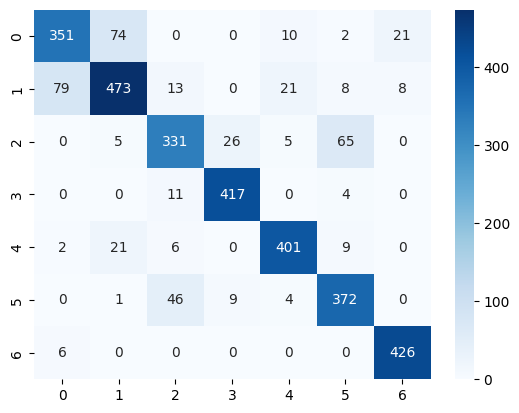

In [18]:
cm = confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cm,cmap="Blues",annot=True,fmt="d")
plt.show()